# <a id='toc1_'></a>[Lag Design](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Lag Design](#toc1_)    
- [RL Lag Design 10-25](#toc2_)    
- [Lag Design on 11-26](#toc3_)    
- [Repeat RL Lag Design Above with tighter spec (10-29)](#toc4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

source = "./"

In [4]:
def writefile(filename, Gc):
    with open(filename+"_zero.txt", "w") as f:
        f.write(str(f"{np.real(-Gc.zeros())[0]:4.3f}"))
    with open(filename+"_pole.txt", "w") as f:
        f.write(str(f"{np.real(-Gc.poles())[0]:4.3f}"))
    with open(filename+"_gain.txt", "w") as f:
        gain = Gc.num[0][0]/Gc.den[0][0]
        f.write(str(f"{gain[0]:4.2f}"))

# <a id='toc2_'></a>[RL Lag Design 10-25](#toc0_)

In [5]:
G = ct.tf((0, 10), np.convolve((1,0),np.convolve((1,5),(1,10))))

# Goals
Mp = 0.2
Ts = 4 # 2%
#
zeta = np.sqrt(np.log(Mp)**2/(np.pi**2+np.log(Mp)**2))
#
wn = 4/zeta/Ts # 2%
wd = wn*np.sqrt(1-zeta**2)

# Target Poles
s0 = np.roots([1, 2*zeta*wn, wn**2])
print(f"{zeta= :.3f}")
print(f"{wn= :.3f}")
print(f"{wd= :.3f}")

zeta= 0.456
wn= 2.193
wd= 1.952


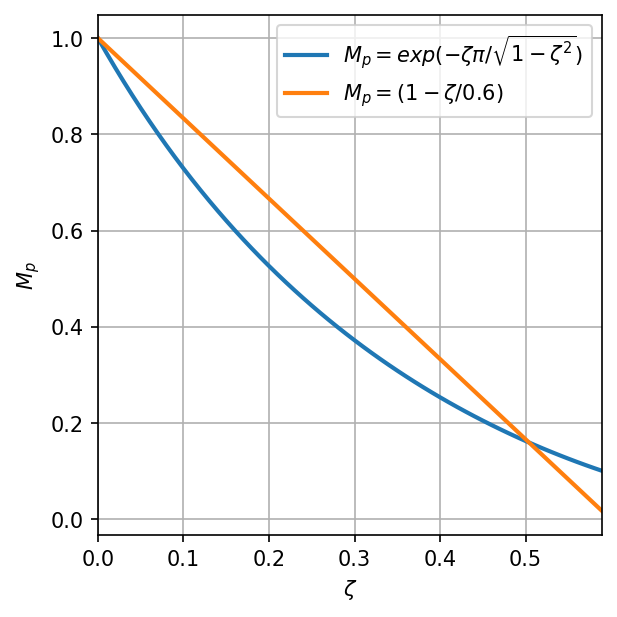

In [6]:
# Check the approximate Mp specification
fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
Zeta = np.arange(0,0.6,1/100)
plt.plot(Zeta,np.exp(-Zeta*np.pi/np.sqrt(1-Zeta**2)),label=r'$M_p = exp(-\zeta\pi/\sqrt{1-\zeta^2})$')
plt.plot(Zeta,(1-Zeta/0.6),label=r'$M_p = (1-\zeta/0.6)$')
plt.xlabel(r'$\zeta$')
plt.ylabel(r'$M_p$')
plt.legend()
plt.show()

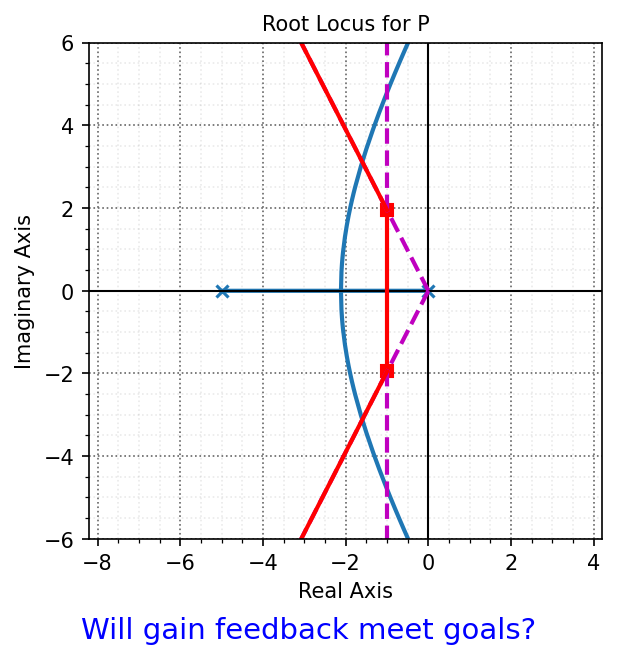

In [7]:
fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(G,ax=ax)
scl = ct.feedback(G,13).poles()

ax.plot(s0.real,s0.imag,'rs',ms=6)
ax.plot(scl[0].real,scl[0].imag,'bo',ms=8)
ax.axis('equal')
ax.set_xlim([-6, 2])
ax.set_ylim([-6, 6])
ax.set_title('Root Locus for P')
bm.nicegrid(ax)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')

plt.plot([-zeta*wn, -zeta*wn],[-wd, wd],'r-')
plt.plot([-zeta*wn, -zeta*wn],[wd, 20],'m--')
plt.plot([-zeta*wn, -zeta*wn],[-wd, -20],'m--')
th = np.arctan(wd/(zeta*wn))
plt.plot([-zeta*wn, -20],[zeta*wn*np.tan(th), 20*np.tan(th)],'m--')
plt.plot([-zeta*wn, -20],[-zeta*wn*np.tan(th), -20*np.tan(th)],'m--')
plt.plot([-0, -zeta*wn],[0, wd],'m--')
plt.plot([-0, -zeta*wn],[0, -wd],'m--')
plt.plot([-zeta*wn, -20],[zeta*wn*np.tan(th), 20*np.tan(th)],'r-')
plt.plot([-zeta*wn, -20],[-zeta*wn*np.tan(th), -20*np.tan(th)],'r-')
cm.caption("Will gain feedback meet goals?",fig,yloc=-0.05)
plt.savefig("./figs/L12_RL_des1.pdf", dpi=600)
plt.show()

# <a id='toc3_'></a>[Lag Design on 11-26](#toc0_)

In [8]:
# Lag Design
Kdesign = 13 
Kv_req = 1/0.05
gamma = 10
b = np.real(abs(s0[0])/gamma)
a =  b/(Kv_req/(G.num[0][0][-1]/G.den[0][0][-2])/Kdesign)

In [34]:
Gc_lag = Kdesign*ct.tf((1, b), (1, a))
L = Gc_lag*G
Lag_gain = np.squeeze(Gc_lag.num)[0]/np.squeeze(Gc_lag.den)[0]
print(f"{Lag_gain = :.3f}")
print(f"{np.real(Gc_lag.zeros()[0]) = :.3f}")
print(f"{np.real(Gc_lag.poles()[0]) = :.3f}")

writefile(source+"Gc_10_27", Gc_lag)

cm.show_tf_latex(Gc_lag,show=True)
msgs = cm.show_tf_latex(Gc_lag)

Lag_gain = 1.000
np.real(Gc_lag.zeros()[0]) = -0.292
np.real(Gc_lag.poles()[0]) = -0.117


<IPython.core.display.Math object>


Found break-in/out at K =  5.293
At possible locations s = -1.960

Found break-in/out at K =  3.883
At possible locations s = -0.564

Found break-in/out at K =  0.073
At possible locations s = -0.066

Found break-in/out at K =  5.293
At possible locations s = -1.960

Found break-in/out at K =  3.883
At possible locations s = -0.564

Found break-in/out at K =  0.073
At possible locations s = -0.066


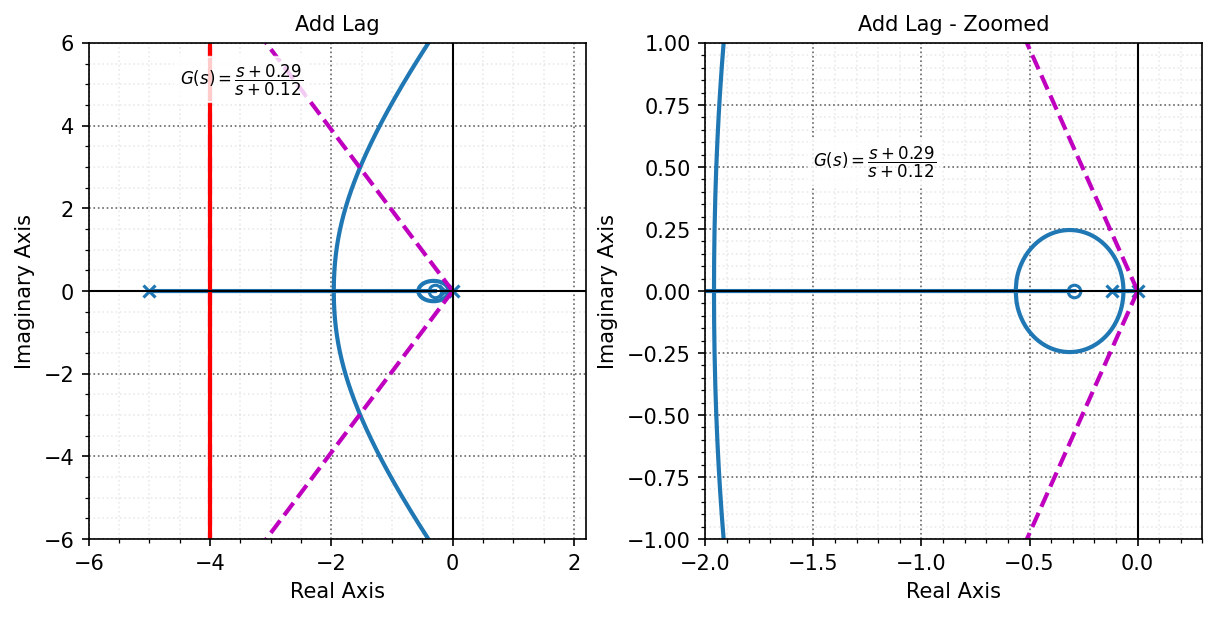

In [ ]:
def plot_rlocus_panel(ax, L, G, s0, zeta, wn, wd,
                      xlim, ylim,
                      title="",
                      show_text=None):

    # root locus
    ct.rlocus(L, gains=cm.Root_Locus_gains(L), ax=ax)

    scl = ct.feedback(G, 1).poles()
    ax.plot(s0.real, s0.imag, 'ms', ms=6)
    ax.plot(scl[0].real, scl[0].imag, 'bo', ms=8)

    # spec geometry
    th = np.arctan(wd / (zeta * wn))

    # damping vertical line
    ax.plot([-zeta*wn, -zeta*wn], [-wd, wd], 'm--')
    ax.plot([-zeta*wn, -zeta*wn], [wd, 20], 'm--')
    ax.plot([-zeta*wn, -zeta*wn], [-wd, -20], 'm--')

    # angle lines
    ax.plot([-zeta*wn, -20], [ zeta*wn*np.tan(th),  20*np.tan(th)], 'm--')
    ax.plot([-zeta*wn, -20], [-zeta*wn*np.tan(th), -20*np.tan(th)], 'm--')

    # connecting lines
    ax.plot([0, -zeta*wn], [0,  wd], 'm--')
    ax.plot([0, -zeta*wn], [0, -wd], 'm--')

    # solid highlight
    ax.plot([-zeta*wn, -zeta*wn], [-wd, wd], 'r-')
    ax.plot([-zeta*wn, -20], [ zeta*wn*np.tan(th),  20*np.tan(th)], 'r-')
    ax.plot([-zeta*wn, -20], [-zeta*wn*np.tan(th), -20*np.tan(th)], 'r-')

    # formatting
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title)
    ax.set_xlabel("Real Axis")
    ax.set_ylabel("Imaginary Axis")
    bm.nicegrid(ax)

    if show_text:
        ax.text(*show_text,fontsize=8,color="black",
                bbox=dict(facecolor="white",edgecolor='white',boxstyle="round,pad=0.3",alpha=0.8))

pad = 0.2
fig, ax = plt.subplots(1,2,figsize=(8,4), dpi=150, constrained_layout=True)
plot_rlocus_panel(ax[0], L, G, s0, zeta, wn, wd,
                  xlim=[-6, 2+pad],
                  ylim=[-6, 6],
                  title="Add Lag",
                  show_text=(-4.5, 5, msgs))

plot_rlocus_panel(ax[1], L, G, s0, zeta, wn, wd,
                  xlim=[-2, .1+pad],
                  ylim=[-1, 1],
                  title="Add Lag - Zoomed",
                  show_text=(-1.5, 0.5, msgs))

fig.canvas.draw()  # important

def save_axis(ax, filename, pad=0.05):
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    bbox = ax.get_tightbbox(renderer)
    bbox = bbox.expanded(1 + pad,1)
    bbox = bbox.transformed(fig.dpi_scale_trans.inverted())

    fig.savefig(filename, bbox_inches=bbox)

save_axis(ax[0], "./figs/L12_RL_des1a.pdf", pad=0.08)
save_axis(ax[1], "./figs/L12_RL_des1a_zoomed.pdf", pad=0.08)


omega_n:	2.885
zeta   :	0.435
Tr     :	0.50s
Ts     :	3.64s
Mp     :	0.22
Tp     :	1.21s
Yss    :	1.02


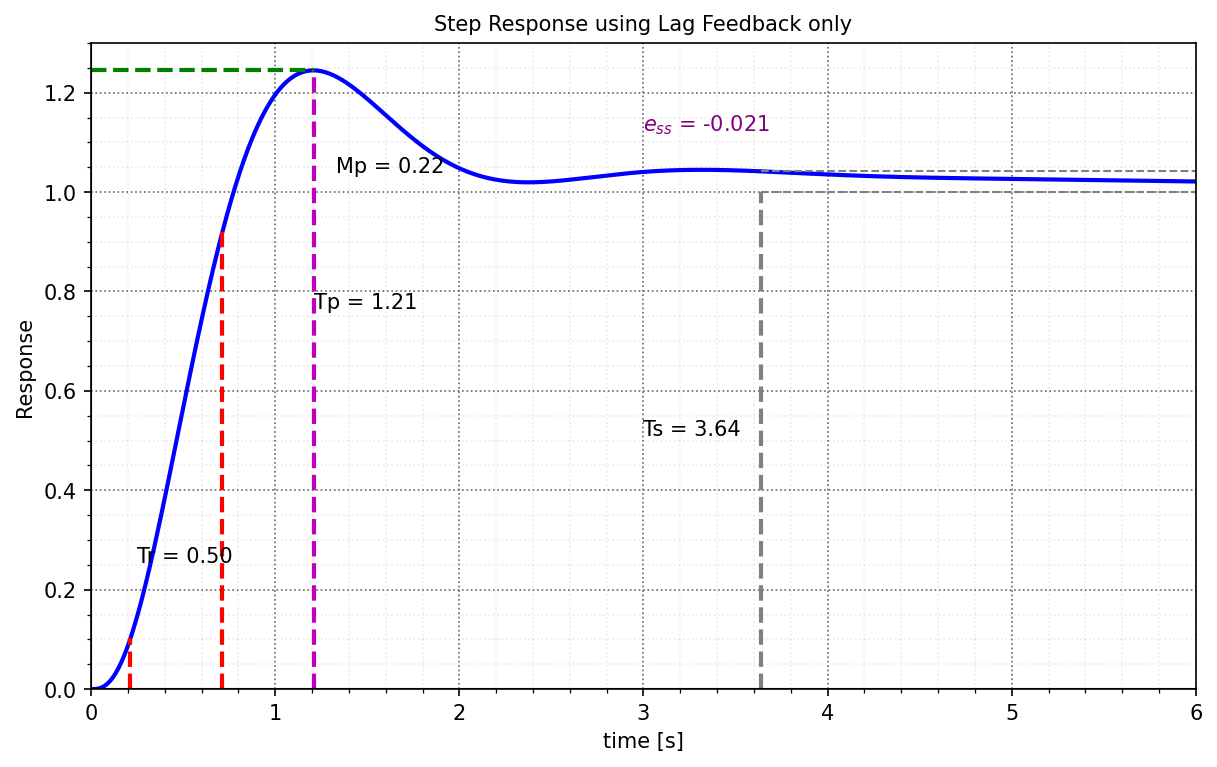

In [30]:
Gcl_lag = ct.feedback(L,1)
y_lag,t_lag = cmat.step(Gcl_lag,6)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
S_lag = cm.Step_info(t_lag,y_lag)
S_lag.printout()
S_lag.nice_plot(ax)
bm.nicegrid(ax)
plt.title("Step Response using Lag Feedback only")
plt.savefig("./figs/L12_RL_des1b.pdf", dpi=600)
plt.show()

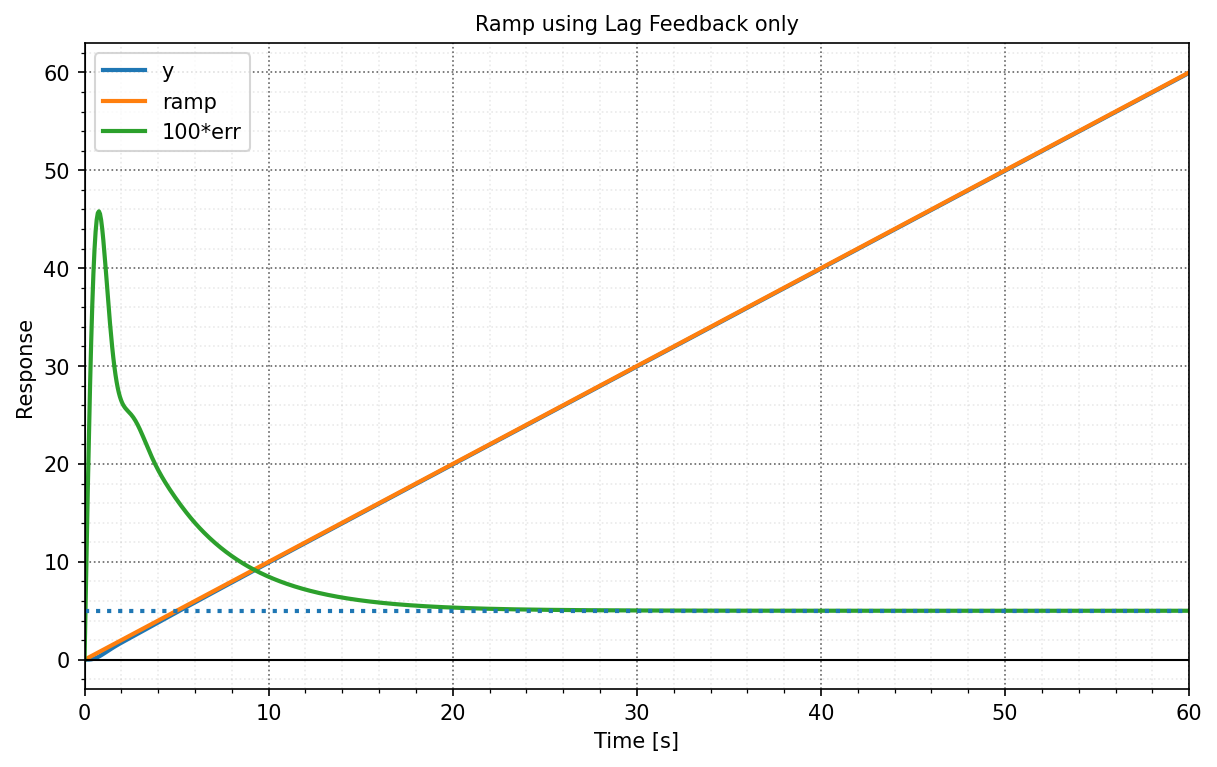

In [29]:
t = np.linspace(0,60,1000)
u = t # for ramp input
y_lag_ramp, t_lag_ramp, _ = cmat.lsim(ct.ss(Gcl_lag), T=t, U=u)

fig, ax = plt.subplots(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t_lag_ramp,y_lag_ramp,label='y')
plt.plot(t_lag_ramp,t_lag_ramp,label='ramp')
plt.plot(t_lag_ramp,100*(t_lag_ramp - y_lag_ramp),label='100*err')
plt.axhline(y=100/Kv_req,ls=':')
bm.nicegrid(ax)
plt.title("Ramp")
plt.xlabel("Time [s]")
plt.ylabel("Response")
plt.legend()
plt.title("Ramp using Lag Feedback only")
plt.savefig("./figs/L12_RL_des1c.pdf", dpi=600)
plt.show()

# <a id='toc4_'></a>[Repeat RL Lag Design Above with tighter spec (10-29)](#toc0_)

In [13]:
G = ct.tf((0, 10), np.convolve((1,0),np.convolve((1,5),(1,10))))
Mp = 0.2
Ts = 1 # decreased from 4 in earlier design
#
zeta = np.sqrt(np.log(Mp)**2/(np.pi**2+np.log(Mp)**2))
#
wn = 4/zeta/Ts # 2%
wd = wn*np.sqrt(1-zeta**2)
# Target Poles
s0 = np.roots([1, 2*zeta*wn, wn**2])
print(f"{zeta= :.3f}")
print(f"{wn= :.3f}")
print(f"{wd= :.3f}")
s0 = np.roots([1, 2*zeta*wn, wn**2])

# Lead lag Design
Kdesign = 13 
Kv_req = 1/0.05
gamma = 20
b = abs(s0[0])/gamma
a =  b/(Kv_req/(G.num[0][0][-1]/G.den[0][0][-2])/Kdesign)

zeta= 0.456
wn= 8.773
wd= 7.808


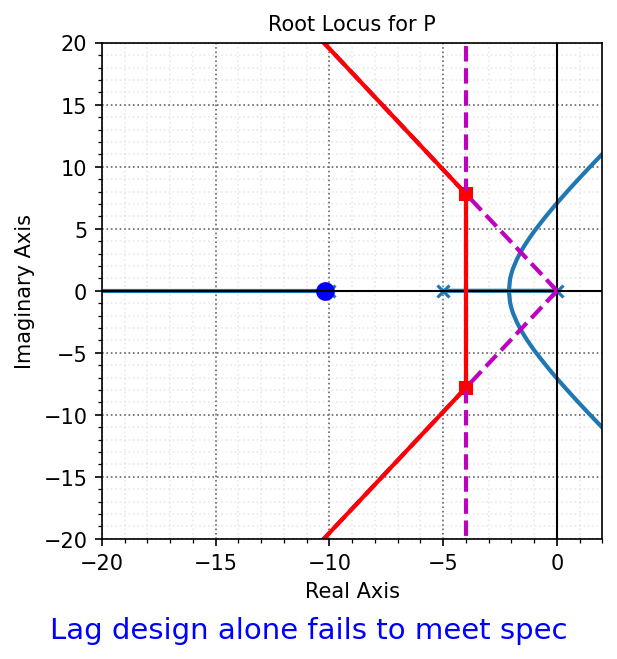

In [14]:
fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(G,ax=ax)
scl = ct.feedback(G,1).poles()

ax.plot(s0.real,s0.imag,'rs',ms=6)
ax.plot(scl[0].real,scl[0].imag,'bo',ms=8)
ax.set_xlim([-20, 2])
ax.set_ylim([-20, 20])
ax.set_title('Root Locus for P')
bm.nicegrid(ax)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')

plt.plot([-zeta*wn, -zeta*wn],[-wd, wd],'m--')
plt.plot([-zeta*wn, -zeta*wn],[wd, 20],'m--')
plt.plot([-zeta*wn, -zeta*wn],[-wd, -20],'m--')
th = np.arctan(wd/(zeta*wn))
plt.plot([-zeta*wn, -20],[zeta*wn*np.tan(th), 20*np.tan(th)],'m--')
plt.plot([-zeta*wn, -20],[-zeta*wn*np.tan(th), -20*np.tan(th)],'m--')
plt.plot([-0, -zeta*wn],[0, wd],'m--')
plt.plot([-0, -zeta*wn],[0, -wd],'m--')

plt.plot([-zeta*wn, -zeta*wn],[-wd, wd],'r-')
plt.plot([-zeta*wn, -20],[zeta*wn*np.tan(th), 20*np.tan(th)],'r-')
plt.plot([-zeta*wn, -20],[-zeta*wn*np.tan(th), -20*np.tan(th)],'r-')

cm.caption("Lag design alone fails to meet spec",fig)
plt.savefig("./figs/L12_RL_des2.pdf", dpi=600)
plt.show()

In [15]:
Gc_lead, scl,_ = cm.Root_Locus_design_cancel(G,s_target = s0[0], s_cancel = -5)
Lead_gain = np.squeeze(Gc_lag.num)[0]/np.squeeze(Gc_lag.den)[0]
print(f"{Lead_gain = :.3f}")
print(f"{Gc_lead.zeros()[0] = :.3f}")
print(f"{Gc_lead.poles()[0] = :.3f}")
L_lead = G*Gc_lead
Gc_lead
        
writefile(source+"Gc_10_30", Gc_lead)

Lead_gain = 13.000
Gc_lead.zeros()[0] = -5.000+0.000j
Gc_lead.poles()[0] = -46.482+0.000j


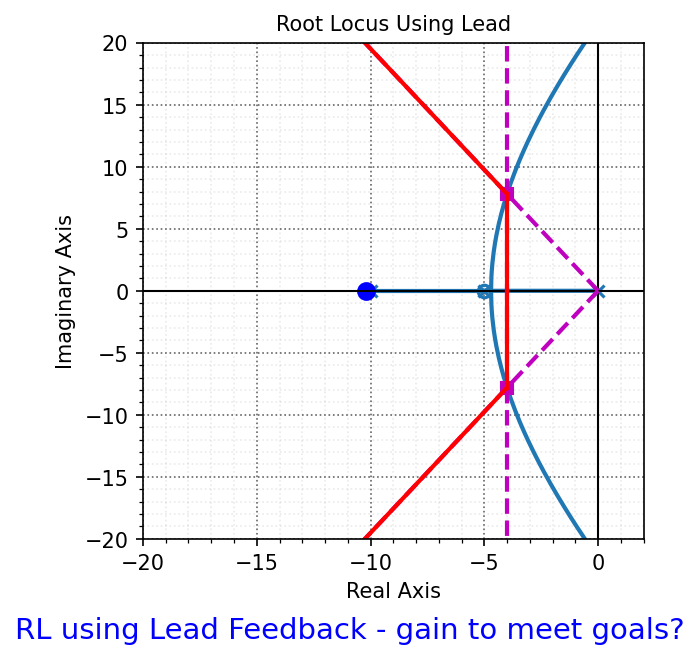

In [16]:
fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(L_lead,ax=ax)
scl = ct.feedback(G,1).poles()

ax.plot(s0.real,s0.imag,'ms',ms=6)
ax.plot(scl[0].real,scl[0].imag,'bo',ms=8)
ax.set_xlim([-20, 2])
ax.set_ylim([-20, 20])
ax.set_title('Root Locus Using Lead')
bm.nicegrid(ax)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')

plt.plot([-zeta*wn, -zeta*wn],[-wd, wd],'m--')
plt.plot([-zeta*wn, -zeta*wn],[wd, 20],'m--')
plt.plot([-zeta*wn, -zeta*wn],[-wd, -20],'m--')
th = np.arctan(wd/(zeta*wn))
plt.plot([-zeta*wn, -20],[zeta*wn*np.tan(th), 20*np.tan(th)],'m--')
plt.plot([-zeta*wn, -20],[-zeta*wn*np.tan(th), -20*np.tan(th)],'m--')
plt.plot([-0, -zeta*wn],[0, wd],'m--')
plt.plot([-0, -zeta*wn],[0, -wd],'m--')

plt.plot([-zeta*wn, -zeta*wn],[-wd, wd],'r-')
plt.plot([-zeta*wn, -20],[zeta*wn*np.tan(th), 20*np.tan(th)],'r-')
plt.plot([-zeta*wn, -20],[-zeta*wn*np.tan(th), -20*np.tan(th)],'r-')

cm.caption("RL using Lead Feedback - gain to meet goals?",fig,yloc=-0.05)
plt.savefig("./figs/L12_RL_des2a.pdf", dpi=600)
plt.show()

In [17]:
# Repeat lag Design with plant (G*Gc_lead)
Kdesign = 1
Kv_req = 1/0.05
gamma = 30
b = abs(s0[0])/gamma
a =  b/(Kv_req/(L_lead.num[0][0][-1]/L_lead.den[0][0][-2])/Kdesign)
Gc_lag = Kdesign*ct.tf((1, b), (1, a))
L_lead_lag = L_lead*Gc_lag

writefile(source+"Gc_10_31", Gc_lag)

cm.show_tf_latex(Gc_lag,r"G_{c_{lag}}")

'$G_{c_{lag}} = \\dfrac{s + 0.29}{s + 0.12}$'

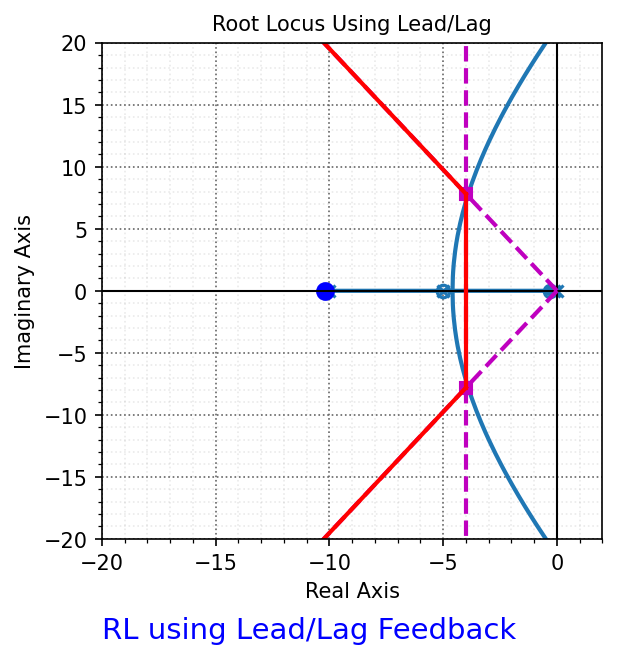

In [18]:
fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(L_lead_lag,ax=ax)
scl = ct.feedback(G,1).poles()

ax.plot(s0.real,s0.imag,'ms',ms=6)
ax.plot(scl[0].real,scl[0].imag,'bo',ms=8)
ax.set_xlim([-20, 2])
ax.set_ylim([-20, 20])
ax.set_title('Root Locus Using Lead/Lag')
bm.nicegrid(ax)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')

plt.plot([-zeta*wn, -zeta*wn],[-wd, wd],'m--')
plt.plot([-zeta*wn, -zeta*wn],[wd, 20],'m--')
plt.plot([-zeta*wn, -zeta*wn],[-wd, -20],'m--')
th = np.arctan(wd/(zeta*wn))
plt.plot([-zeta*wn, -20],[zeta*wn*np.tan(th), 20*np.tan(th)],'m--')
plt.plot([-zeta*wn, -20],[-zeta*wn*np.tan(th), -20*np.tan(th)],'m--')
plt.plot([-0, -zeta*wn],[0, wd],'m--')
plt.plot([-0, -zeta*wn],[0, -wd],'m--')

plt.plot([-zeta*wn, -zeta*wn],[-wd, wd],'r-')
plt.plot([-zeta*wn, -20],[zeta*wn*np.tan(th), 20*np.tan(th)],'r-')
plt.plot([-zeta*wn, -20],[-zeta*wn*np.tan(th), -20*np.tan(th)],'r-')

cm.caption("RL using Lead/Lag Feedback",fig,yloc=-0.05)
plt.savefig("./figs/L12_RL_des2aa.pdf", dpi=600)
plt.show()

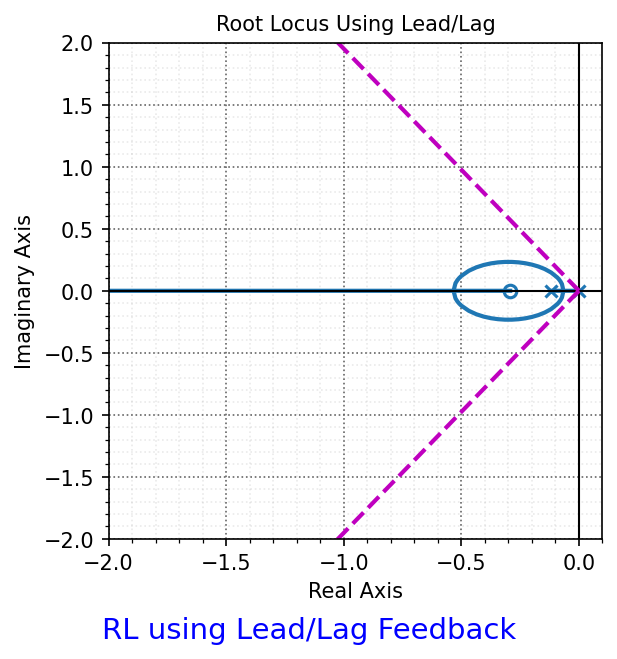

In [19]:
fig, ax = plt.subplots(figsize=(4, 4),dpi=150,constrained_layout = True)
ct.rlocus(L_lead_lag, ax=ax)
scl = ct.feedback(L_lead_lag,1).poles()

ax.plot(s0.real,s0.imag,'ms',ms=6)
ax.plot(scl[0].real,scl[0].imag,'bo',ms=8)
ax.set_xlim([-2, .1])
ax.set_ylim([-2, 2])
ax.set_title('Root Locus Using Lead/Lag')
bm.nicegrid(ax)
ax.set_xlabel('Real Axis')
ax.set_ylabel('Imaginary Axis')

plt.plot([-zeta*wn, -zeta*wn],[-wd, wd],'m--')
plt.plot([-zeta*wn, -zeta*wn],[wd, 20],'m--')
plt.plot([-zeta*wn, -zeta*wn],[-wd, -20],'m--')
th = np.arctan(wd/(zeta*wn))
plt.plot([-zeta*wn, -20],[zeta*wn*np.tan(th), 20*np.tan(th)],'m--')
plt.plot([-zeta*wn, -20],[-zeta*wn*np.tan(th), -20*np.tan(th)],'m--')
plt.plot([-0, -zeta*wn],[0, wd],'m--')
plt.plot([-0, -zeta*wn],[0, -wd],'m--')

plt.plot([-zeta*wn, -zeta*wn],[-wd, wd],'r-')
plt.plot([-zeta*wn, -20],[zeta*wn*np.tan(th), 20*np.tan(th)],'r-')
plt.plot([-zeta*wn, -20],[-zeta*wn*np.tan(th), -20*np.tan(th)],'r-')

cm.caption("RL using Lead/Lag Feedback",fig,yloc=-0.05)
plt.savefig("./figs/L12_RL_des2aa_zoom.pdf", dpi=600)
plt.show()

omega_n:	8.187
zeta   :	0.440
Tr     :	0.18s
Ts     :	0.95s
Mp     :	0.21
Tp     :	0.43s
Yss    :	1.01


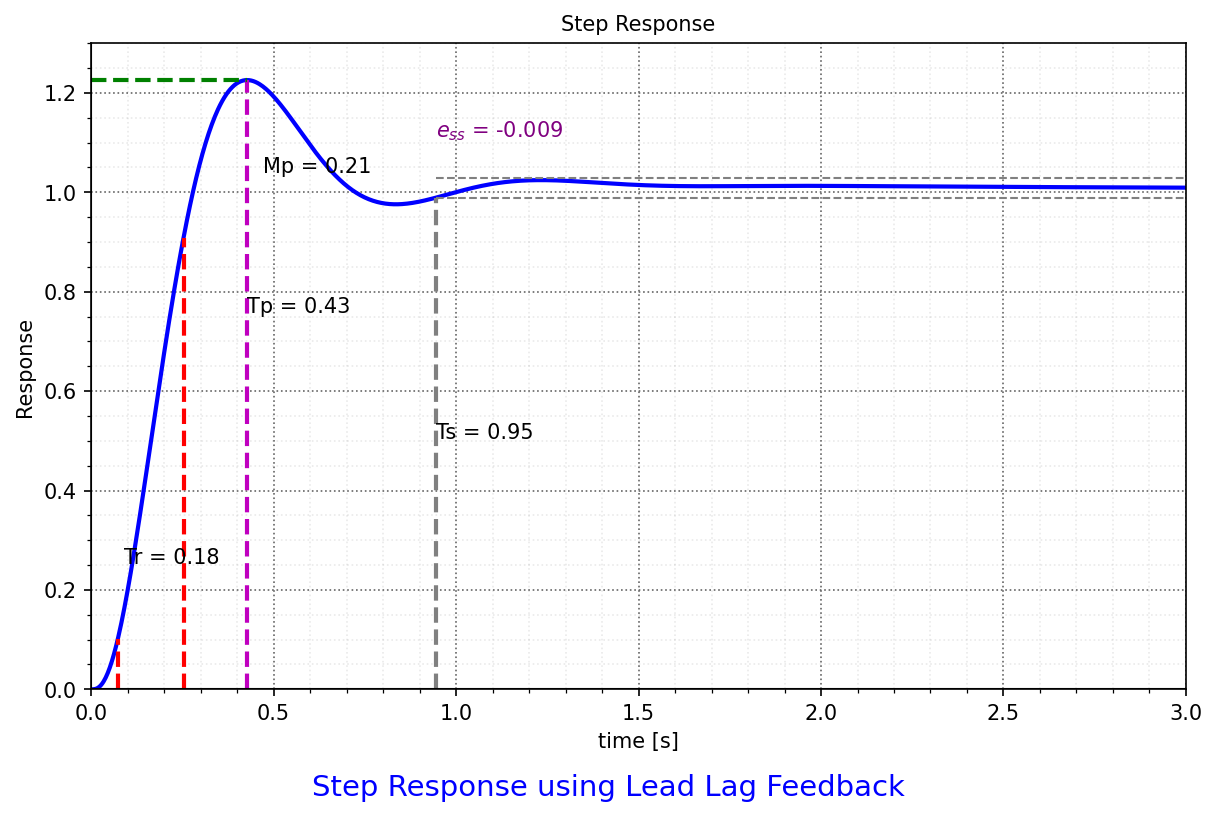

In [20]:
Gcl_lead_lag = ct.feedback(L_lead_lag,1)
y_lead_lag,t_lead_lag = cmat.step(Gcl_lead_lag,3)

fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
S_lead_lag = cm.Step_info(t_lead_lag,y_lead_lag)
S_lead_lag.printout()
S_lead_lag.nice_plot(ax)
bm.nicegrid(ax)
cm.caption("Step Response using Lead Lag Feedback",fig,yloc=-0.05)
plt.savefig("./figs/L12_RL_des2b.pdf", dpi=600)
plt.show()

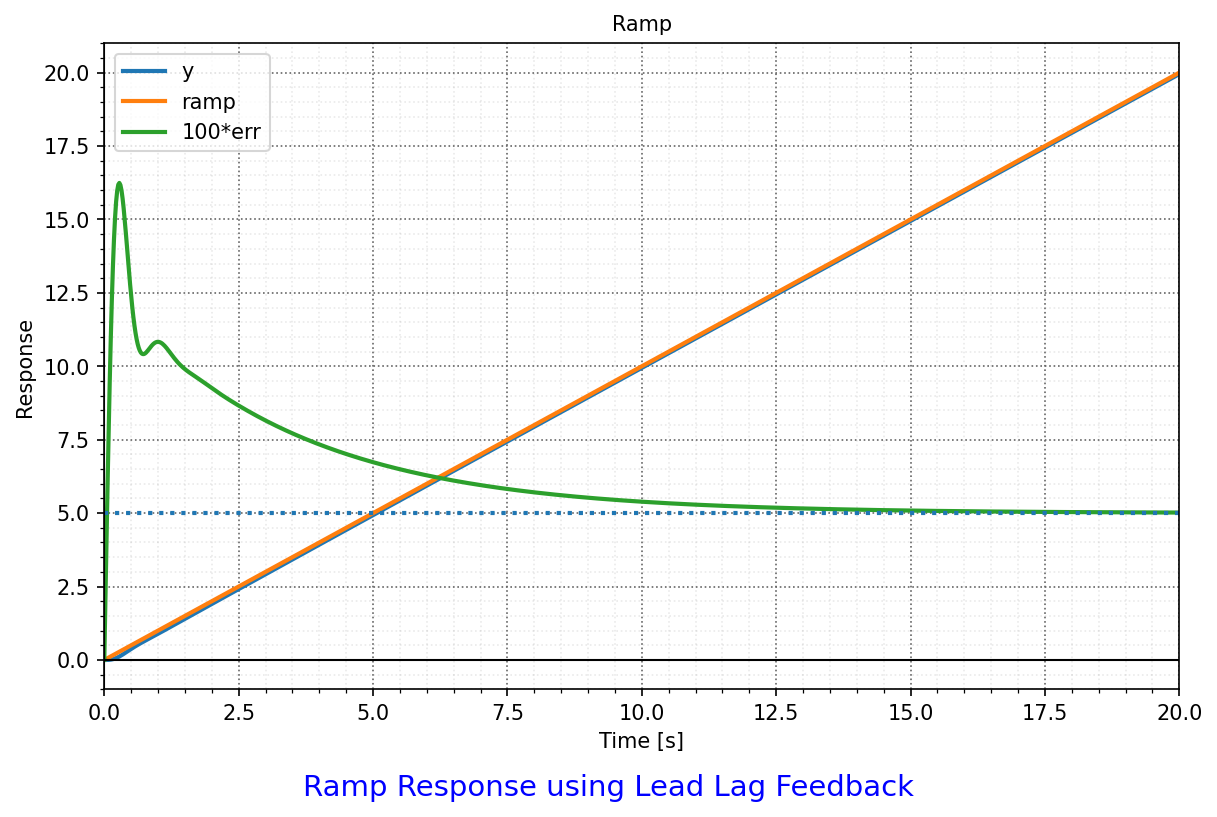

In [21]:
t = np.linspace(0,20,1000)
y_lead_lag_ramp, t_lead_lag_ramp, x_lead_lag_ramp = cmat.lsim(ct.tf2ss(Gcl_lead_lag), T=t, U=t)

fig, ax = plt.subplots(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(t_lead_lag_ramp,y_lead_lag_ramp,label='y')
plt.plot(t_lead_lag_ramp,t_lead_lag_ramp,label='ramp')
plt.plot(t_lead_lag_ramp,100*(t_lead_lag_ramp - y_lead_lag_ramp),label='100*err')
plt.axhline(y=100/Kv_req,ls=':')
bm.nicegrid(ax)
plt.title("Ramp")
plt.xlabel("Time [s]")
plt.ylabel("Response")
plt.legend()
cm.caption("Ramp Response using Lead Lag Feedback",fig,yloc=-0.05)
plt.savefig("./figs/L12_RL_des2c.pdf", dpi=600)
plt.show()